<a href="https://colab.research.google.com/github/shuodeng521-sys/NEW_REPO/blob/main/HW5_ShuoDeng.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ST554 HW 5
##Shuo Deng

#Part I - Concepts

##1. Example: Big Data in Wellness Tracking
Wearable wellness devices such as Apple Watch or Fitbit generate big data through continuous health monitoring. They clearly demonstrate the Five V’s of Big Data.

**Volume** — Devices collect large amounts of data every day, including heart rate, sleep stages, steps, and stress indicators, creating a massive long‑term dataset.

**Velocity** — Data is recorded and uploaded continuously, often every second, showing high‑speed real‑time data flow.

**Variety** — The system captures numerical sensor data, time‑series signals, GPS information, and lifestyle logs, representing diverse data types.

**Veracity** — Sensor readings can be noisy or inaccurate due to motion, device placement, or environmental factors, so data quality is not always perfect.

**Value** — The data helps users improve sleep, reduce stress, optimize exercise, and build healthier habits, creating meaningful personal wellness benefits.


###2. Preparation

In [4]:
# read in PART 4 data to check the table name
import sqlite3
con = sqlite3.connect("/lahman_1871-2022.sqlite")
cursor = con.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
cursor.fetchall()


[('AllstarFull',),
 ('Appearances',),
 ('AwardsManagers',),
 ('AwardsPlayers',),
 ('AwardsShareManagers',),
 ('AwardsSharePlayers',),
 ('Batting',),
 ('BattingPost',),
 ('CollegePlaying',),
 ('Fielding',),
 ('FieldingOF',),
 ('FieldingOFsplit',),
 ('FieldingPost',),
 ('HallOfFame',),
 ('HomeGames',),
 ('Managers',),
 ('ManagersHalf',),
 ('Parks',),
 ('People',),
 ('Pitching',),
 ('PitchingPost',),
 ('Salaries',),
 ('Schools',),
 ('SeriesPost',),
 ('Teams',),
 ('TeamsFranchises',),
 ('TeamsHalf',)]

In [5]:
cursor.close()

##2. CRUD examples: the Baseball Archive SQLite database  
**Create** — Insert a new player into the People table, such as adding a newly drafted player with a new playerID, first name, last name, and birth information.

**Read** — Query the Batting table to retrieve a player’s hitting statistics for a specific season.

**Update** — Modify a player’s team assignment in the Appearances table if they were traded, by updating the teamID for that season.

**Delete** — Remove an incorrect or duplicate defensive record from the Fielding table to keep the dataset accurate.

##3. HAVING clause  
SQLite HAVING clause to specify a filter condition for a group or an aggregate such as COUNT(), SUM(), AVG(), MAX(), or MIN(). It works together with GROUP BY to keep only the groups that meet a specified aggregate condition.

#Part II - Simulation of a Sampling Distribution

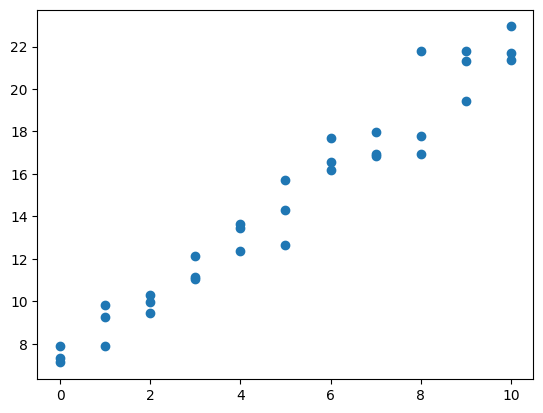

In [6]:
# copy the code from hw5 instruction
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = 33
#create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1*x + rng.standard_normal(n)
#visualize the data
plt.scatter(x = x, y = y)
plt.show()

### The true regression line is defined(beta value) and the 𝑥-values remain fixed across all simulations. Only the random error term changes in each iteration, which causes the estimated slope to vary from sample to sample. The collection of 5000 slope estimates forms an empirical approximation to the sampling distribution of the slope estimator under this model:


In [7]:
#Import the LinearRegression model from sklearn
from sklearn.linear_model import LinearRegression
# Create an empty list to store the estimated slopes
slopes = []
# Set the true intercept and slope for the simulation
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each interger from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
# Repeat the simulation 5000 times
for i in range(5000):
    # Generate y values with random noise added
    y = beta_0 + beta_1 * x + rng.standard_normal(n)
    # Fit the simple linear regression model using sklearn
    model = LinearRegression().fit(x.reshape(-1,1), y)
    # Save the estimated slope from this iteration
    slopes.append(model.coef_[0])


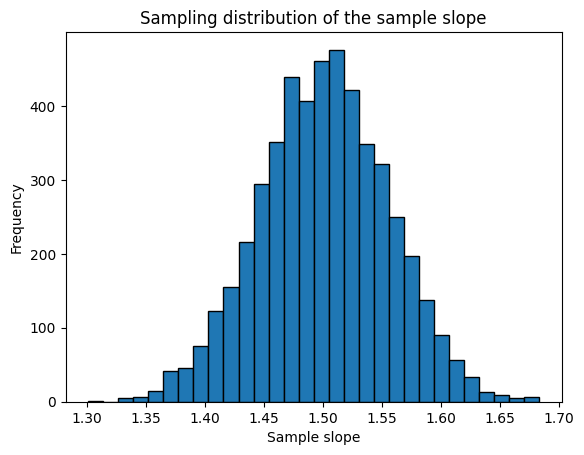

In [7]:
import matplotlib.pyplot as plt
# Create a histogram of the simulated sample slopes
plt.hist(slopes, bins=30, edgecolor='black')
plt.xlabel('Sample slope')
plt.ylabel('Frequency')
plt.title('Sampling distribution of the sample slope')
plt.show()

In [8]:
import numpy as np
# Approximate the probability of observing a sample slope larger than 1.65
prob_greater_165 = np.mean(np.array(slopes) > 1.65)
prob_greater_165

np.float64(0.0032)

##Interpretation the relation ship between the value and hypothesis test
The estimated probability of observing a sample slope larger than 1.65 is approximately 0.0032. This value represents how likely it is to obtain such a large slope purely due to random sampling variability if the true slope is actually 1.5.
Because 0.0032 is so small, a slope as large as 1.65 is very unlikely under the null, which gives strong evidence that the true slope is greater than 1.5.

#Part III - Big Data Examples & Rare Events

##5. Bias in machine learning models
（1）One example in the article is reporting bias from social media data. Machine learning models may use online posts to study violence in conflict areas. But many local people do not post online, and many posts are only in English. This means the data does not fully represent what is really happening. Some events or groups may be under-reported.

（2）To reduce this bias, researchers can use more data sources, like local reports and interviews, and include more local languages. They can also adjust the model to account for missing groups. This can make the results more fair and accurate.

##6. Big data usage in Earth Sciences
One of the main areas the paper talks about is hydrology, which is the study of water on Earth (like rain, rivers, soil moisture, and groundwater). In this area, big data is used by collecting huge amounts of information from satellites, weather stations, river sensors, and computer models. Scientists use this large amount of data to better understand how water moves around the planet and to predict things like floods and droughts. Because there is so much data from many places and many years, computers and machine learning programs help analyze it faster and find patterns that people might not see on their own.

However, there can still be problems with the data. First, not all places on Earth have good data. Some remote or poor areas do not have many sensors, so scientists might be missing information there. Second, different tools and satellites may measure things in slightly different ways, which can cause small errors. Third, if computer models are trained mostly on data from certain countries, they may not work as well in other regions.

So even though big data gives scientists much more information than before, the results can still be affected by missing data, uneven coverage, or measurement errors. It is important to always think about where the data comes from and what might not be included.

##7. Rare Events
Another situation where understanding rare events is important is earthquakes. Most of the time the ground does not shake, but the rare large earthquakes cause the most damage. If we only look at all earthquakes together, we might miss how unusual and dangerous the big ones are. So statisticians study rare, large earthquakes separately to better predict risk and prepare safety plans.

#Part IV - Querying a database

##8.Connect to the database

In [2]:
import sqlite3
import pandas as pd
con = sqlite3.connect("/lahman_1871-2022.sqlite")
#create a 'cursor' object from our connection
cursor = con.cursor()
#SQL query to return all table names in the data base
get_schema = '''
        SELECT *
        FROM sqlite_schema
        WHERE type = "table";
        '''
#return the data
pd.read_sql(get_schema,con)


,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


##9.returns all the teams that played in the year 2015 with all of the corresponding columns from the Teams table

In [31]:
#CHECK column name of Team table
pd.read_sql("PRAGMA table_info(Teams);", con)

,cid,name,type,notnull,dflt_value,pk
0,0,yearID,INTEGER,0,None,0
1,1,lgID,TEXT,0,None,0
2,2,teamID,TEXT,0,None,0
3,3,franchID,TEXT,0,None,0
4,4,divID,TEXT,0,None,0
5,5,Rank,INTEGER,0,None,0
6,6,G,INTEGER,0,None,0
7,7,Ghome,INTEGER,0,None,0
8,8,W,INTEGER,0,None,0
9,9,L,INTEGER,0,None,0


In [32]:
#use filter to show year =2015
pd.read_sql("SELECT*FROM Teams WHERE yearID=2015",con)

,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,2015,AL,BAL,BAL,E,3,162,78,81,81,...,134,0.987,Baltimore Orioles,Oriole Park at Camden Yards,2281202,103,104,BAL,BAL,BAL
1,2015,AL,BOS,BOS,E,5,162,81,78,84,...,148,0.984,Boston Red Sox,Fenway Park II,2880694,104,107,BOS,BOS,BOS
2,2015,AL,CHA,CHW,C,4,162,81,76,86,...,159,0.983,Chicago White Sox,U.S. Cellular Field,1755810,92,93,CHW,CHA,CHA
3,2015,AL,CLE,CLE,C,3,161,80,81,80,...,136,0.987,Cleveland Indians,Progressive Field,1388905,106,106,CLE,CLE,CLE
4,2015,AL,DET,DET,C,5,161,81,74,87,...,165,0.986,Detroit Tigers,Comerica Park,2726048,97,98,DET,DET,DET
5,2015,AL,HOU,HOU,W,2,162,81,86,76,...,131,0.986,Houston Astros,Minute Maid Park,2153585,97,99,HOU,HOU,HOU
6,2015,AL,KCA,KCR,C,1,162,81,95,67,...,138,0.985,Kansas City Royals,Kauffman Stadium,2708549,104,103,KCR,KCA,KCA
7,2015,AL,LAA,ANA,W,3,162,81,85,77,...,108,0.984,Los Angeles Angels of Anaheim,Angel Stadium of Anaheim,3012765,94,95,LAA,ANA,ANA
8,2015,AL,MIN,MIN,C,2,162,81,83,79,...,150,0.986,Minnesota Twins,Target Field,2220054,103,104,MIN,MIN,MIN
9,2015,AL,NYA,NYY,E,2,162,81,87,75,...,135,0.985,New York Yankees,Yankee Stadium III,3193795,99,101,NYY,NYA,NYA


##10.returns all of the players in the hall of fame, the year they were voted into the hall of fame, and their category

In [33]:
#CHECK column name of HallofFame table
pd.read_sql("PRAGMA table_info(HallOfFame);", con)

,cid,name,type,notnull,dflt_value,pk
0,0,playerID,TEXT,0,None,0
1,1,yearid,INTEGER,0,None,0
2,2,votedBy,TEXT,0,None,0
3,3,ballots,INTEGER,0,None,0
4,4,needed,INTEGER,0,None,0
5,5,votes,INTEGER,0,None,0
6,6,inducted,TEXT,0,None,0
7,7,category,TEXT,0,None,0
8,8,needed_note,TEXT,0,None,0


In [34]:
# check the table content
pd.read_sql(""" SELECT playerID, yearID, inducted, category FROM HallOfFame
LIMIT 10;""", con)

,playerID,yearid,inducted,category
0,aaronha01,1982,Y,Player
1,abbotji01,2005,N,Player
2,abreubo01,2020,N,Player
3,abreubo01,2021,N,Player
4,abreubo01,2022,N,Player
5,adamsba01,1937,N,Player
6,adamsba01,1938,N,Player
7,adamsba01,1939,N,Player
8,adamsba01,1942,N,Player
9,adamsba01,1945,N,Player


In [35]:
#returns all of the players in the hall of fame, the year they were voted into the hall of fame, and their categor, which inducted variable eaqual to Y
query = """
SELECT playerID, yearID, category
FROM HallOfFame
WHERE inducted = 'Y';
"""
pd.read_sql(query, con)

,playerID,yearid,category
0,aaronha01,1982,Player
1,alexape01,1938,Player
2,alomaro01,2011,Player
3,alstowa01,1983,Manager
4,andersp01,2000,Manager
...,...,...,...
335,yastrca01,1989,Player
336,yawketo99,1980,Pioneer/Executive
337,youngcy01,1937,Player
338,youngro01,1972,Player


## 11. return all unique managers of the Pittsburgh Pirates (teamID of PIT) and only that information from the Managers table

In [36]:
# check the table content
pd.read_sql("PRAGMA table_info(Managers);", con)

,cid,name,type,notnull,dflt_value,pk
0,0,playerID,TEXT,0,None,0
1,1,yearID,INTEGER,0,None,0
2,2,teamID,TEXT,0,None,0
3,3,lgID,TEXT,0,None,0
4,4,inseason,INTEGER,0,None,0
5,5,G,INTEGER,0,None,0
6,6,W,INTEGER,0,None,0
7,7,L,INTEGER,0,None,0
8,8,rank,INTEGER,0,None,0
9,9,plyrMgr,TEXT,0,None,0


In [37]:
# return all unique managers of the Pittsburgh Pirates (teamID of PIT) and only that information from the Managers table
query="""
 SELECT DISTINCT
   teamID
   FROM Managers
   WHERE teamID='PIT';
   """
pd.read_sql(query,con)

,teamID
0,PIT


##12. return all of the playerIDs for the people that managed for a team that were inducted into the hall of fame. Also, programmatically report the number of such people

In [39]:
#use INNER JOIN to combine HallofFame and Mangers table
#use Distinct to show the unique playerID
inner="""
SELECT DISTINCT m.playerID
From Managers as m
INNER JOIN HallOfFame as h ON m.playerID=h.playerID
WHERE h.inducted = 'Y';
"""
df=pd.read_sql(inner,con)
#count playerID and print
count_people = df['playerID'].nunique()
print(df)
print("Number of people:", count_people)

     playerID
0   alstowa01
1   andersp01
2   ansonca01
3   applilu01
4   baineha01
..        ...
92  willidi02
93  willite01
94  wrighge01
95  wrighha01
96  youngcy01

[97 rows x 1 columns]
Number of people: 97


##13(1).return every season managed by each manager that made it to the hall of fame

In [42]:
#CHECK column name of Managers table
pd.read_sql("PRAGMA table_info(Managers);", con)

,cid,name,type,notnull,dflt_value,pk
0,0,playerID,TEXT,0,None,0
1,1,yearID,INTEGER,0,None,0
2,2,teamID,TEXT,0,None,0
3,3,lgID,TEXT,0,None,0
4,4,inseason,INTEGER,0,None,0
5,5,G,INTEGER,0,None,0
6,6,W,INTEGER,0,None,0
7,7,L,INTEGER,0,None,0
8,8,rank,INTEGER,0,None,0
9,9,plyrMgr,TEXT,0,None,0


In [54]:
# check the Managers table content
pd.read_sql(""" SELECT DISTINCT playerID, yearID, inseason, W, L FROM Managers
LIMIT 20;""", con)

,playerID,yearID,inseason,W,L
0,wrighha01,1871,1,20,10
1,woodji01,1871,1,19,9
2,paborch01,1871,1,10,19
3,lennobi01,1871,1,5,9
4,deaneha01,1871,2,2,3
5,fergubo01,1871,1,16,17
6,mcbridi01,1871,1,21,7
7,hastisc01,1871,1,4,21
8,pikeli01,1871,1,1,3
9,cravebi01,1871,2,12,12


In [52]:
query = """
SELECT DISTINCT m.yearID, m.inseason, m.playerID, m.G, m.W, m.L
FROM Managers AS m
INNER JOIN HallOfFame AS h
ON m.playerID = h.playerID
WHERE h.inducted = 'Y'
ORDER BY m.yearID, m.inseason, m.playerID;
"""

df = pd.read_sql(query, con)
df

,yearID,inseason,playerID,G,W,L
0,1871,1,wrighha01,31,20,10
1,1872,1,wrighha01,48,39,8
2,1872,2,whitede01,2,0,2
3,1873,1,wrighha01,60,43,16
4,1874,1,wrighha01,71,52,18
...,...,...,...,...,...,...
991,2016,1,molitpa01,162,59,103
992,2017,1,molitpa01,162,85,77
993,2018,1,molitpa01,162,78,84
994,2021,1,larusto01,160,92,68


##13.(2)determine the overall win/loss records (sum of wins and sum of losses for each of these hall of fame managers. (3)create a new variable that is the win/loss percentage (W/(W+L)). Lastly, sort the resulting data by the win/loss percentage variable (from largest to smallest)

In [3]:
#group by playerID and sum each manager's win and loss
query = """
SELECT
    m.playerID,
    SUM(m.W),
    SUM(m.L),
    1.0*SUM(m.W) / (SUM(m.W) + SUM(m.L)) as win_pct
FROM Managers AS m
INNER JOIN HallOfFame AS h
ON m.playerID = h.playerID
WHERE h.inducted = 'Y'
GROUP BY m.playerID
ORDER BY win_pct DESC;
"""

pd.read_sql(query, con)

,playerID,SUM(m.W),SUM(m.L),win_pct
0,simmote01,1,0,1.000000
1,wrighge01,59,25,0.702381
2,spaldal01,78,47,0.624000
3,mccarjo99,2125,1333,0.614517
4,comisch01,840,541,0.608255
...,...,...,...,...
92,bottoji01,21,56,0.272727
93,applilu01,10,30,0.250000
94,baineha01,1,3,0.250000
95,wagneho01,1,4,0.200000
